You must install the tqdm library to use progress indicators with emcee


MCMC simülasyonu çalıştırılıyor, uzayın derinliklerine iniliyor...


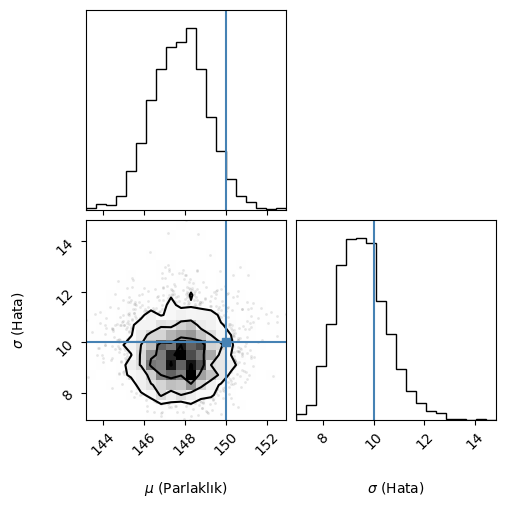


--- RAPOR TABLOSU (BÖLÜM 5.1) İÇİN DEĞERLER ---
μ (Parlaklık) -> Median: 147.79 | Alt Sınır (%16): 146.43 | Üst Sınır (%84): 149.07
σ (Hata Payı) -> Median: 9.49 | Alt Sınır (%16): 8.55 | Üst Sınır (%84): 10.53


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

# --- 1. Veri Oluşturma (Sentetik Gözlem) ---
true_mu = 150.0   # Gerçek parlaklık
true_sigma = 10.0 # Gözlem hatası
n_obs = 50        # Gözlem sayısı

np.random.seed(42)
data = true_mu + true_sigma * np.random.randn(n_obs)

# --- 2. Bayesyen Fonksiyonların Tanımlanması ---
def log_likelihood(theta, data):
    mu, sigma = theta
    if sigma <= 0: 
        return -np.inf # Fiziksel olmayan durum
    # PDF'teki formülün Numpy ile yazılmış hali:
    return -0.5 * np.sum(((data - mu) / sigma)**2 + np.log(2 * np.pi * sigma**2))

def log_prior(theta):
    mu, sigma = theta
    if 0 < mu < 300 and 0 < sigma < 50: # Geniş ve informatif olmayan bir sınır
        return 0.0
    return -np.inf

def log_probability(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

# --- 3. MCMC Örnekleyiciyi Çalıştırma ---
initial = [140, 5]
n_walkers = 32
ndim = 2
pos = initial + 1e-4 * np.random.randn(n_walkers, ndim)

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(data,))
print("MCMC simülasyonu çalıştırılıyor, uzayın derinliklerine iniliyor...")
sampler.run_mcmc(pos, 2000, progress=True)

# --- 4. Sonuçların Görselleştirilmesi ---
# İlk 500 adımı 'burn-in' olarak atıyoruz
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=[r"$\mu$ (Parlaklık)", r"$\sigma$ (Hata)"],
    truths=[true_mu, true_sigma]
)
plt.show()

# --- 5. Ödev Raporu İçin Tablo Değerlerinin Hesaplanması ---
mu_mcmc = np.percentile(flat_samples[:, 0], [16, 50, 84])
sigma_mcmc = np.percentile(flat_samples[:, 1], [16, 50, 84])

print("\n--- RAPOR TABLOSU (BÖLÜM 5.1) İÇİN DEĞERLER ---")
print(f"μ (Parlaklık) -> Median: {mu_mcmc[1]:.2f} | Alt Sınır (%16): {mu_mcmc[0]:.2f} | Üst Sınır (%84): {mu_mcmc[2]:.2f}")
print(f"σ (Hata Payı) -> Median: {sigma_mcmc[1]:.2f} | Alt Sınır (%16): {sigma_mcmc[0]:.2f} | Üst Sınır (%84): {sigma_mcmc[2]:.2f}")
